# Deep Learning Capstone — CIFAR-10 Image Classification

## Project Overview

This project develops and evaluates fully connected **Dense Neural Networks** for image classification using the **CIFAR-10 dataset**.

The notebook follows a complete experimental workflow, starting with a simple baseline model and progressively evaluating different network architectures, hyperparameters, and regularization techniques before selecting and evaluating a Final Model.

### Project Workflow

The notebook includes:

1. **Data Loading and Preprocessing**
   - Load and inspect the CIFAR-10 dataset
   - Normalize pixel values
   - Split the data into training, validation, and test sets
   - Flatten each 32×32×3 image into a 3072-dimensional input vector

2. **Baseline Model**
   - Build and train a simple Dense Neural Network
   - Establish baseline training and validation performance

3. **Architecture Comparison**
   - Compare Shallow, Medium, and Deep Dense Neural Networks
   - Analyze learning curves and identify overfitting

4. **Hyperparameter Optimization**
   - Tune the learning rate
   - Compare batch sizes
   - Compare optimizers

5. **Regularization Experiments**
   - Dropout
   - L2 Regularization
   - Batch Normalization
   - Early Stopping

6. **Final Model Selection and Evaluation**
   - Select the final configuration based on validation evidence
   - Evaluate the Final Model on the untouched test set
   - Analyze class-level performance and common classification errors

7. **Experiment Tracking and Conclusion**
   - Compare all major experiments
   - Summarize the experimental findings
   - Discuss the limitations of Dense Neural Networks for image data

### Scope

This project intentionally uses **fully connected Dense Neural Networks only**. Convolutional Neural Networks (CNNs), pretrained models, and transfer learning are not used.

The goal is not only to improve classification performance, but also to understand how **network depth, hyperparameters, regularization, and model architecture affect training and generalization** on image data.

## Setup

Import libraries and fix the random seed. The same seed is reused everywhere in Parts 1–8 so that experiments are reproducible and comparable.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Fixed random seed for reproducibility across the whole notebook
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


---
# Part 1 — Dataset Understanding

We use the **CIFAR-10** dataset: 60,000 32×32 color images in 10 classes (50,000 train + 10,000 test).

In [ ]:
# Load CIFAR-10
(X_train_full, y_train_full), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training set shape (images):", X_train_full.shape)
print("Training set shape (labels):", y_train_full.shape)
print("Test set shape (images):    ", X_test_raw.shape)
print("Test set shape (labels):    ", y_test_raw.shape)

print("\nSingle image dimensions:", X_train_full.shape[1:], "(height x width x channels)")
print("Number of classes:", len(class_names))
print("Class names:", class_names)

print("\nPixel value range: min =", X_train_full.min(), " max =", X_train_full.max())


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1386s 8us/step
Training set shape (images): (50000, 32, 32, 3)
Training set shape (labels): (50000, 1)
Test set shape (images):     (10000, 32, 32, 3)
Test set shape (labels):     (10000, 1)

Single image dimensions: (32, 32, 3) (height x width x channels)
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Pixel value range: min = 0  max = 255


In [ ]:
# Number of examples per class (training set)
unique, counts = np.unique(y_train_full, return_counts=True)
print("Number of training examples per class:")
for u, c in zip(unique, counts):
    print(f"  {class_names[int(u)]:<12}: {c}")


Number of training examples per class:
  airplane    : 5000
  automobile  : 5000
  bird        : 5000
  cat         : 5000
  deer        : 5000
  dog         : 5000
  frog        : 5000
  horse       : 5000
  ship        : 5000
  truck       : 5000


/tmp/ipykernel_939/3512347532.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train_full[idx])])


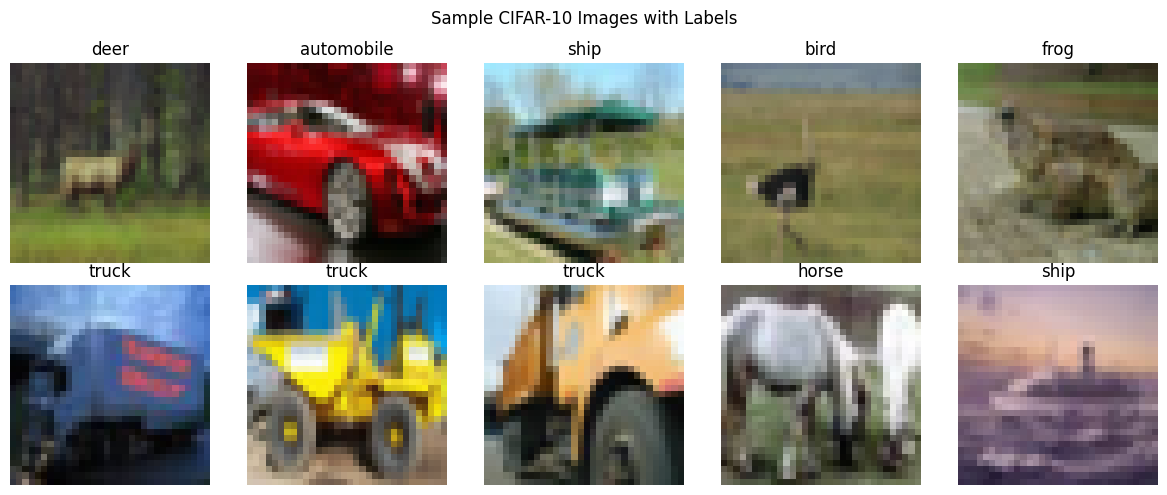

In [ ]:
# Display at least 10 sample images with their labels
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train_full), size=10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(sample_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[idx])
    plt.title(class_names[int(y_train_full[idx])])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images with Labels")
plt.tight_layout()
plt.show()


### Dataset Understanding — Questions

**What does one sample represent?**
One sample is a single 32×32 color (RGB) photograph of an object belonging to exactly one of the 10 CIFAR-10 categories (e.g., a picture of a cat, a picture of a truck).

**What is the target variable?**
The target variable is the integer class label (0–9), where each integer corresponds to one of the 10 object categories listed in `class_names`.

**Is this a binary or multiclass classification problem?**
It is a **multiclass classification problem** with 10 mutually exclusive classes (not binary, since there are more than two possible labels).

**What does 32 × 32 × 3 represent?**
It represents the shape of a single image: 32 pixels of height, 32 pixels of width, and 3 color channels (Red, Green, Blue).

**Why does the output layer require 10 neurons?**
Because there are 10 possible, mutually exclusive classes. Each output neuron corresponds to one class and (with a softmax activation) outputs the predicted probability that the input image belongs to that class. The 10 probabilities sum to 1.


---
# Part 2 — Data Preparation

We now prepare the data for a **Dense Neural Network**:
1. Normalize pixel values to the [0, 1] range.
2. Flatten each 32×32×3 image into a vector of 3072 values.
3. Split the original training set into a Training Set and a Validation Set (the original CIFAR-10 test set is kept aside as the final Test Set and will **not** be touched again until Part 16).

The same split (same `SEED`) is reused for every experiment in this notebook so that architecture and hyperparameter comparisons are fair.

In [ ]:
# 1. Normalize pixel values to [0, 1]
X_train_full_norm = X_train_full.astype('float32') / 255.0
X_test_norm = X_test_raw.astype('float32') / 255.0

# 2. Flatten images: 32 x 32 x 3 -> 3072
X_train_full_flat = X_train_full_norm.reshape(X_train_full_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

# Flatten label arrays from shape (N,1) to (N,)
y_train_full_flat = y_train_full.flatten()
y_test_flat = y_test_raw.flatten()

print("Flattened training feature shape:", X_train_full_flat.shape)
print("Flattened test feature shape:    ", X_test_flat.shape)


Flattened training feature shape: (50000, 3072)
Flattened test feature shape:     (10000, 3072)


In [ ]:
# 3. Split into Training Set and Validation Set (stratified, fixed seed)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full_flat,
    y_train_full_flat,
    test_size=0.1,          # 10% of training data reserved for validation
    random_state=SEED,
    stratify=y_train_full_flat
)

# Final Test Set (untouched until Part 16)
X_test = X_test_flat
y_test = y_test_flat

print("Final data shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)


Final data shapes:
X_train: (45000, 3072)
X_val:   (5000, 3072)
X_test:  (10000, 3072)
y_train: (45000,)
y_val:   (5000,)
y_test:  (10000,)


**Notes on the split:**
- The Training/Validation split uses `test_size=0.1` with `stratify` on the labels, so class proportions are preserved in both sets. With 50,000 original training images this yields approximately 45,000 training / 5,000 validation images — the exact numbers are printed by the cell above.
- The Test Set (10,000 images) is completely separate and is **not** used anywhere in Parts 1–8, consistent with the project rule of reserving it for final evaluation only.
- This exact split (same `SEED`, same `test_size`) is reused for every model trained in this notebook (Baseline, Shallow, Medium, Deep) to keep comparisons fair.


---
# Part 3 — Build a Baseline Neural Network

A simple Dense Neural Network with one hidden layer, used as a reference point before exploring deeper architectures.

In [ ]:
def build_baseline_model():
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(128, activation='relu', name='hidden_layer'),
        layers.Dense(10, activation='softmax', name='output_layer')
    ], name="Baseline_Network")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()


Model: "Baseline_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BASELINE_EPOCHS = 20
BASELINE_BATCH_SIZE = 64

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=BASELINE_EPOCHS,
    batch_size=BASELINE_BATCH_SIZE,
    verbose=1
)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3147 - loss: 1.9235 - val_accuracy: 0.3508 - val_loss: 1.8150
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3735 - loss: 1.7674 - val_accuracy: 0.3854 - val_loss: 1.7429
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3950 - loss: 1.7062 - val_accuracy: 0.3962 - val_loss: 1.6969
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4106 - loss: 1.6681 - val_accuracy: 0.4018 - val_loss: 1.6736
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4194 - loss: 1.6418 - val_accuracy: 0.4044 - val_loss: 1.6819
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4263 - loss: 1.6208 - val_accuracy: 0.4126 - val_loss: 1.6703
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4335 - loss: 1.6040 - val_accuracy: 0.4106 - val_loss: 1.6838
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4384 - loss: 1.5884 - val_acc

In [88]:
print("Number of layers:", len(model.layers))
print("Number of trainable parameters:", model.count_params())

Number of layers: 6
Number of trainable parameters: 1748266




## Baseline Model — Report

- **Number of layers:** 6
- **Number of trainable parameters:** 1,748,266
- **Hidden-layer activation:** ReLU
- **Output activation:** Softmax
- **Loss function:** Sparse Categorical Crossentropy
- **Optimizer:** Adam (learning rate = 0.001)
- **Batch size:** 64
- **Epochs:** 20 (chosen as a reasonable starting point for a baseline; not yet tuned)

### Explain

**Why ReLU for the hidden layer?**
ReLU (`f(x) = max(0, x)`) is computationally cheap, does not saturate for positive inputs (unlike sigmoid/tanh), and helps mitigate the vanishing-gradient problem, which generally makes networks train faster and more reliably.

**Why Softmax for the output layer?**
This is a multiclass, mutually-exclusive classification problem. Softmax converts the 10 raw output scores (logits) into a probability distribution that sums to 1, so the output can be directly interpreted as "probability the image belongs to class i."

**Why Sparse Categorical Crossentropy as the loss function?**
The labels (`y_train`, `y_val`) are stored as plain integers (0–9) rather than one-hot vectors. Sparse categorical crossentropy is the correct loss for integer-encoded, multiclass, mutually-exclusive labels paired with a softmax output — it avoids having to manually one-hot encode the labels.


---
# Part 4 — Architecture Experiment

We investigate the effect of **network depth** by building three Dense architectures that differ only in depth:

- **Model 1 — Shallow Network:** 1 hidden layer
- **Model 2 — Medium Network:** 3 hidden layers
- **Model 3 — Deep Network:** 5 hidden layers

All other settings (data, preprocessing, seed, optimizer, learning rate, batch size, max epochs) are kept identical across the three models — this is enforced in Part 5.

In [ ]:
# Hyperparameters kept FIXED across Shallow / Medium / Deep for a fair comparison (Part 5)
COMMON_LR = 0.001
COMMON_BATCH_SIZE = 64
COMMON_EPOCHS = 30
COMMON_OPTIMIZER_NAME = "Adam"

def build_shallow_model():
    """Model 1 - Shallow Network: 1 hidden layer"""
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name="Shallow_Network")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=COMMON_LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_medium_model():
    """Model 2 - Medium Network: 3 hidden layers"""
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name="Medium_Network")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=COMMON_LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_deep_model():
    """Model 3 - Deep Network: 5 hidden layers"""
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name="Deep_Network")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=COMMON_LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
# Model 1 - Shallow Network
shallow_model = build_shallow_model()
shallow_model.summary()


Model: "Shallow_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model 2 - Medium Network
medium_model = build_medium_model()
medium_model.summary()


Model: "Medium_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model 3 - Deep Network
deep_model = build_deep_model()
deep_model.summary()


Model: "Deep_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,748,266 (6.67 MB)

 Trainable params: 1,748,266 (6.67 MB)

 Non-trainable params: 0 (0.00 B)

**Trainable parameters per model:** read directly from each `model.summary()` call above — record the "Total params" / "Trainable params" line for each of the three models here:

- Shallow Network trainable parameters: 789,258
- Medium Network trainable parameters: 1,738,890
- Deep Network trainable parameters: 1,748,266

Note: neuron counts (256 / 512-256-128 / 512-256-128-64-32) were chosen to give each network reasonable capacity while keeping the comparison about **depth**, not about wildly different total capacity.


---
# Part 5 — Fair Model Comparison

To isolate the effect of **depth only**, the following are kept identical across all three models:

| Fixed factor | Value |
|---|---|
| Training data | `X_train, y_train` |
| Validation data | `X_val, y_val` |
| Preprocessing | normalized [0,1], flattened to 3072 |
| Random seed | `SEED = 42` |
| Optimizer | Adam |
| Learning rate | `COMMON_LR = 0.001` |
| Batch size | `COMMON_BATCH_SIZE = 64` |
| Max epochs | `COMMON_EPOCHS = 30` |

No Dropout, L2 Regularization, Early Stopping, or Batch Normalization is used in this comparison — those are reserved for Parts 9–14.

Each model below is **rebuilt from scratch** (fresh weights, same seed) immediately before training, so no model starts from partially-trained weights.

In [ ]:
# Rebuild fresh copies right before training so every model starts from fresh, seeded weights
shallow_model = build_shallow_model()
medium_model = build_medium_model()
deep_model = build_deep_model()

print("Training Shallow Network...")
shallow_history = shallow_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=COMMON_EPOCHS,
    batch_size=COMMON_BATCH_SIZE,
    verbose=1
)


Training Shallow Network...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3172 - loss: 1.9206 - val_accuracy: 0.3428 - val_loss: 1.8187
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3822 - loss: 1.7370 - val_accuracy: 0.3840 - val_loss: 1.7089
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4097 - loss: 1.6611 - val_accuracy: 0.3996 - val_loss: 1.6748
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4268 - loss: 1.6137 - val_accuracy: 0.4112 - val_loss: 1.6452
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4381 - loss: 1.5826 - val_accuracy: 0.4172 - val_loss: 1.6393
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4480 - loss: 1.5573 - val_accuracy: 0.4204 - val_loss: 1.6341
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4563 - loss: 1.5359 - val_accuracy: 0.4258 - val_loss: 1.6169
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accura

In [ ]:
print("Training Medium Network...")
medium_history = medium_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=COMMON_EPOCHS,
    batch_size=COMMON_BATCH_SIZE,
    verbose=1
)


Training Medium Network...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.3156 - loss: 1.8821 - val_accuracy: 0.3522 - val_loss: 1.7714
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.3893 - loss: 1.6902 - val_accuracy: 0.3910 - val_loss: 1.6742
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.4242 - loss: 1.6020 - val_accuracy: 0.4146 - val_loss: 1.6191
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.4476 - loss: 1.5418 - val_accuracy: 0.4254 - val_loss: 1.6079
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4629 - loss: 1.4964 - val_accuracy: 0.4228 - val_loss: 1.5999
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4764 - loss: 1.4636 - val_accuracy: 0.4350 - val_loss: 1.5668
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.4881 - loss: 1.4299 - val_accuracy: 0.4490 - val_loss: 1.5519
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accurac

In [ ]:
print("Training Deep Network...")
deep_history = deep_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=COMMON_EPOCHS,
    batch_size=COMMON_BATCH_SIZE,
    verbose=1
)


Training Deep Network...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.2936 - loss: 1.9272 - val_accuracy: 0.3202 - val_loss: 1.8508
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3728 - loss: 1.7282 - val_accuracy: 0.3870 - val_loss: 1.7143
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.4082 - loss: 1.6347 - val_accuracy: 0.3970 - val_loss: 1.6591
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.4323 - loss: 1.5731 - val_accuracy: 0.4030 - val_loss: 1.6537
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.4508 - loss: 1.5266 - val_accuracy: 0.4158 - val_loss: 1.6372
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.4617 - loss: 1.4901 - val_accuracy: 0.4352 - val_loss: 1.5999
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4762 - loss: 1.4569 - val_accuracy: 0.4400 - val_loss: 1.5757
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy:

---
# Part 6 — Learning Curves

For each of the three networks we plot Training vs. Validation Loss, and Training vs. Validation Accuracy, then interpret the curves.

**Do not skip the written interpretation** — a plot alone is not a diagnosis.

In [ ]:
def plot_history(history, title):
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, hist['loss'], label='Training Loss')
    plt.plot(epochs_range, hist['val_loss'], label='Validation Loss')
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, hist['accuracy'], label='Training Accuracy')
    plt.plot(epochs_range, hist['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


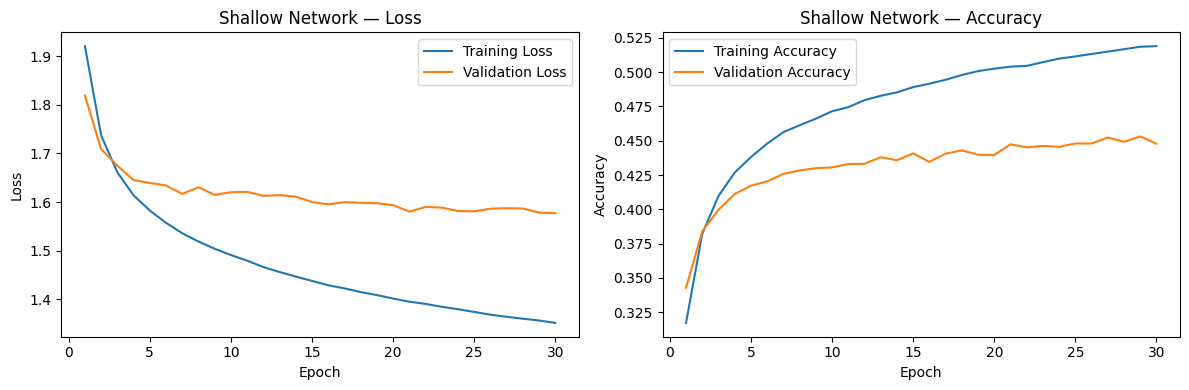

In [ ]:
plot_history(shallow_history, "Shallow Network")


**Shallow Network — Interpretation :**

Diagnosis: Overfitting
Training loss continued to decrease and training accuracy increased, while validation accuracy improved only slightly and then plateaued around 45%. The growing gap between training and validation performance indicates overfitting.

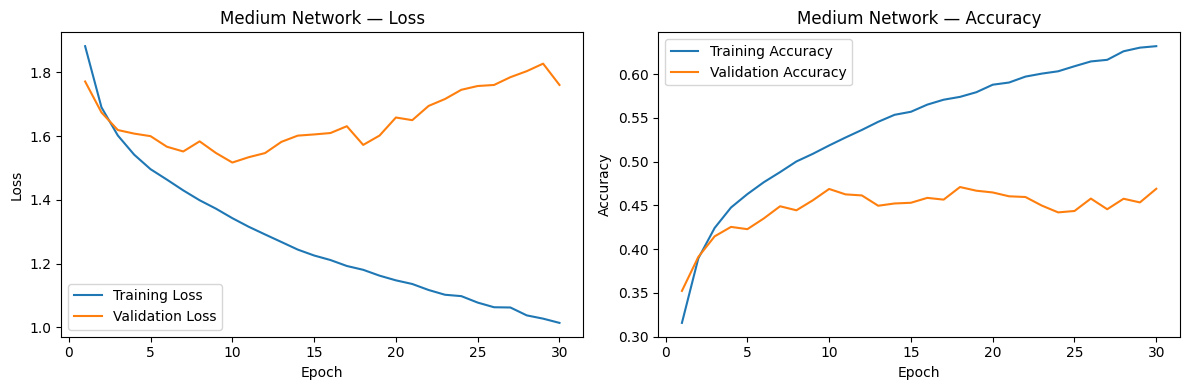

In [ ]:
plot_history(medium_history, "Medium Network")


**Medium Network — Interpretation :**

Diagnosis: Overfitting
Training accuracy continued increasing to about 63%, while validation accuracy remained around 45–47%. Validation loss started increasing after reaching its minimum, while training loss continued decreasing. This is clear evidence of overfitting.


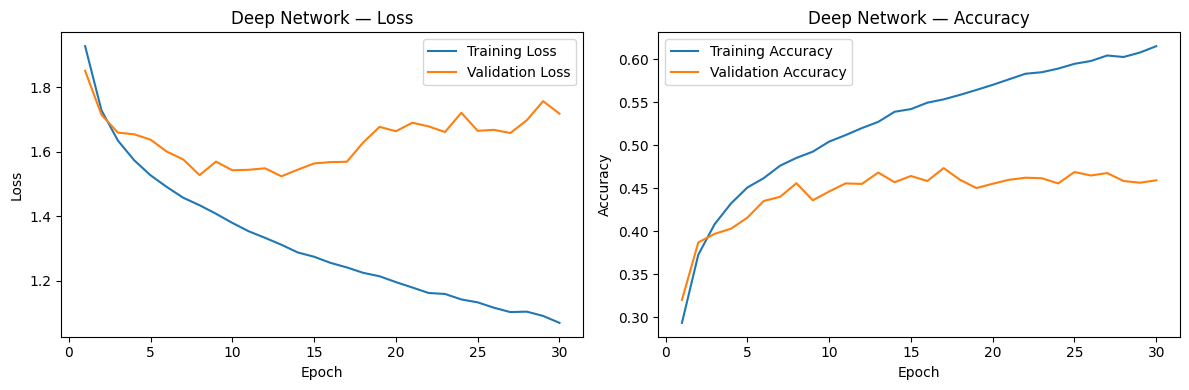

In [ ]:
plot_history(deep_history, "Deep Network")


**Deep Network — Interpretation :**


Diagnosis: Overfitting
Training accuracy continued to improve to about 61%, while validation accuracy remained around 45–47%. Validation loss decreased initially but then increased while training loss continued to decrease, showing that the deeper network was overfitting.

---
# Part 7 — Architecture Comparison

Summary table built directly from the training histories above (no invented numbers — every value is computed from `shallow_history`, `medium_history`, `deep_history`).

In [87]:
def get_metrics(history):
    hist = history.history
    best_train_acc = max(hist['accuracy'])
    best_val_acc = max(hist['val_accuracy'])
    min_val_loss = min(hist['val_loss'])
    return best_train_acc, best_val_acc, min_val_loss

rows = []
for name, history, model in [
    ("Shallow", shallow_history, shallow_model),
    ("Medium",  medium_history,  medium_model),
    ("Deep",    deep_history,    deep_model),
]:
    best_train_acc, best_val_acc, min_val_loss = get_metrics(history)
    # number of hidden layers = total layers minus the output layer
    n_hidden = len(model.layers) - 1
    rows.append({
        "Model": name,
        "Hidden Layers": n_hidden,
        "Parameters": model.count_params(),
        "Best Train Acc.": round(best_train_acc, 4),
        "Best Val Acc.": round(best_val_acc, 4),
        "Min Val Loss": round(min_val_loss, 4),
"Diagnosis": "Overfitting"
    })

comparison_df = pd.DataFrame(rows)
comparison_df


,Model,Hidden Layers,Parameters,Best Train Acc.,Best Val Acc.,Min Val Loss,Diagnosis
0,Shallow,1,789258,0.5190,0.4532,1.5771,Overfitting
1,Medium,3,1738890,0.6321,0.4710,1.5172,Overfitting
2,Deep,5,1748266,0.6150,0.4734,1.5235,Overfitting




### Questions (answer only after the table above is populated with real results)

1. Which architecture learned the Training Data best?
The Medium Network, with the highest training accuracy of 0.6321.

2. Which architecture achieved the best Validation performance?
The Deep Network, with the highest validation accuracy of 0.4734.

3. Which model showed the largest gap between Training and Validation accuracy?
The Medium Network showed the largest gap between training and validation accuracy.

4. Did increasing depth always improve performance?
No. Increasing depth slightly improved validation accuracy from Shallow to Medium and Deep, but the improvement was small and did not consistently improve training performance.

5. Which model showed the strongest evidence of overfitting?
The Medium Network showed the largest train-validation accuracy gap, while both Medium and Deep showed clear overfitting in their learning curves.

6. Which architecture will you continue with in the next stage?
The Medium Network was selected for the next stage.

7. Why did you select it?
The Medium Network was selected because it achieved strong validation performance (0.4710), very close to the Deep Network (0.4734), while using a less complex architecture. Since the validation improvement from increasing the depth further was negligible, the Medium Network provides a better balance between model complexity and validation performance.


---
# Part 8 — Model Diagnosis

Before any tuning happens, we diagnose the architecture selected in Part 7.

> All three sub-sections below must be completed **after** running Parts 1–7 and reading the actual curves/table — they are left as placeholders here on purpose.

Observation

The Medium Network learned the training data well, but its validation performance stopped improving much earlier. Training accuracy continued increasing while validation accuracy remained around 47%, and validation loss began to rise after reaching its minimum.

Diagnosis

☑ Overfitting

Evidence

The Medium Network achieved a best training accuracy of 0.6321 but only 0.4710 validation accuracy, giving a noticeable train-validation gap of about 0.1611. In the learning curves, training loss continued decreasing while validation loss started increasing after approximately epoch 10, which indicates overfitting.

First Proposed Improvement

The first step is to tune the learning rate because optimization settings can strongly affect convergence and validation performance. After selecting an appropriate learning rate, regularization techniques can be tested to reduce overfitting.


---
---
# Parts 9–20 — After Optimization

This section continues directly from **Part 8**. It reuses the same `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test` created in Part 2 (the split is never recreated or modified), and builds on the same fixed `SEED`.

Every experiment below:
- builds a **fresh model with fresh weights** before training,
- changes **only the one variable being tested**, keeping everything else fixed,
- and does **not** touch `X_test` / `y_test` until Part 16.

Wherever a decision would normally require *judgment about real results* (e.g., "which learning rate is best"), the notebook computes it automatically from the actual validation metrics produced when you run the cells — nothing here is a guessed number. Wherever a decision requires judgment about the experimental results (e.g., which learning rate performs best), the notebook bases that decision on the actual validation metrics produced by the experiments. All interpretations and conclusions below are written using the observed results and learning curves as evidence.


---
## Part 9 — Learning Rate Experiment

We continue with the architecture selected in Part 8. Update `SELECTED_ARCHITECTURE` below to match whatever Part 8 concluded (it defaults to `"medium"` as a reasonable placeholder until Part 8 is finalized with real results).

We compare learning rates **0.01, 0.001, 0.0001**, keeping architecture, data, seed, optimizer (Adam), batch size, and max epochs fixed — only the learning rate changes.

In [ ]:
# ---------------------------------------------------------------
# Architecture carried over from Part 8.
# Architecture selected from Part 8 based on the validation results.

# Allowed values: "shallow", "medium", "deep"
# ---------------------------------------------------------------
SELECTED_ARCHITECTURE = "medium"

_ARCH_BUILDERS = {
    "shallow": build_shallow_model,
    "medium": build_medium_model,
    "deep": build_deep_model,
}

_ARCH_HIDDEN_UNITS = {
    "shallow": [256],
    "medium": [512, 256, 128],
    "deep": [512, 256, 128, 64, 32],
}


def build_selected_model(learning_rate=COMMON_LR, optimizer_name="adam", momentum=0.0):
    """Rebuilds the architecture selected in Part 8 with fresh, seeded weights.
    The number/width of hidden layers never changes here - only learning_rate,
    optimizer_name, and momentum are varied, so later experiments stay controlled."""
    tf.random.set_seed(SEED)
    builder = _ARCH_BUILDERS[SELECTED_ARCHITECTURE]
    model = builder()  # builds with fresh weights (default Adam/COMMON_LR compile)

    if optimizer_name == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    else:
        raise ValueError(f"Unknown optimizer_name: {optimizer_name}")

    # Recompiling only changes the optimizer/loss/metrics, not the already-initialized weights
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


print("Selected architecture carried over from Part 8:", SELECTED_ARCHITECTURE)
build_selected_model().summary()


Selected architecture carried over from Part 8: medium


Model: "Medium_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
learning_rates_to_test = [0.01, 0.001, 0.0001]
LR_EPOCHS = COMMON_EPOCHS      # same epoch budget as the Part 5 comparison
LR_BATCH_SIZE = COMMON_BATCH_SIZE

lr_histories = {}

for lr in learning_rates_to_test:
    print(f"\n--- Training with learning rate = {lr} ---")
    model = build_selected_model(learning_rate=lr, optimizer_name="adam")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=LR_EPOCHS,
        batch_size=LR_BATCH_SIZE,
        verbose=1
    )
    lr_histories[lr] = history



--- Training with learning rate = 0.01 ---
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2132 - loss: 2.3805 - val_accuracy: 0.2146 - val_loss: 2.0206
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.2493 - loss: 1.9668 - val_accuracy: 0.2740 - val_loss: 1.9324
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.2569 - loss: 1.9506 - val_accuracy: 0.2210 - val_loss: 2.0013
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.2574 - loss: 1.9434 - val_accuracy: 0.2124 - val_loss: 2.0361
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.2596 - loss: 1.9405 - val_accuracy: 0.2408 - val_loss: 1.9569
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.2642 - loss: 1.9361 - val_accuracy: 0.2286 - val_loss: 1.9881
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.2638 - loss: 1.9275 - val_accuracy: 0.2358 - val_loss: 1.9749
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33

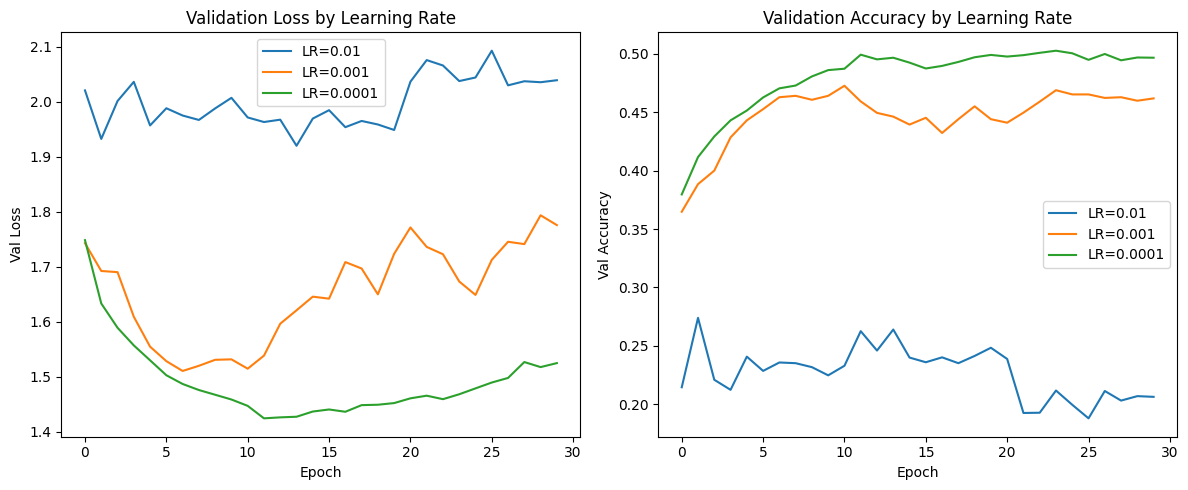

In [ ]:
# Compare convergence / stability across learning rates
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for lr, history in lr_histories.items():
    plt.plot(history.history['val_loss'], label=f'LR={lr}')
plt.title('Validation Loss by Learning Rate')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()

plt.subplot(1, 2, 2)
for lr, history in lr_histories.items():
    plt.plot(history.history['val_accuracy'], label=f'LR={lr}')
plt.title('Validation Accuracy by Learning Rate')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()

plt.tight_layout()
plt.show()


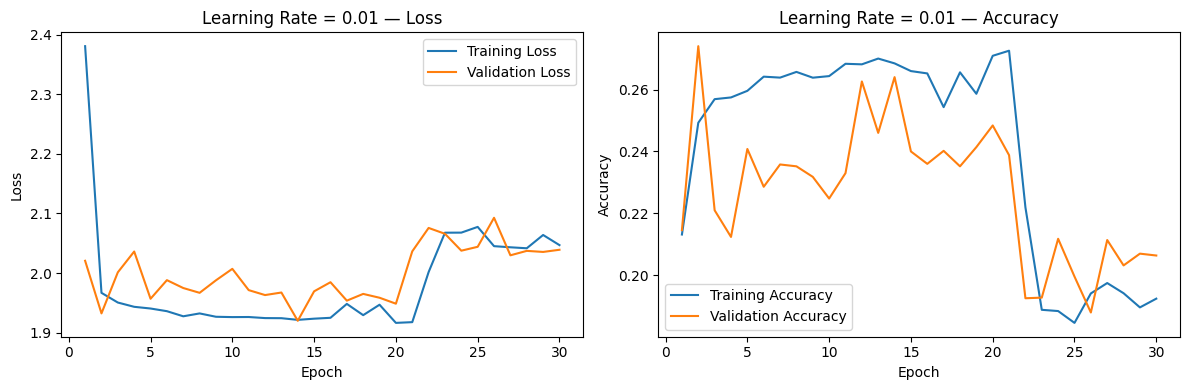

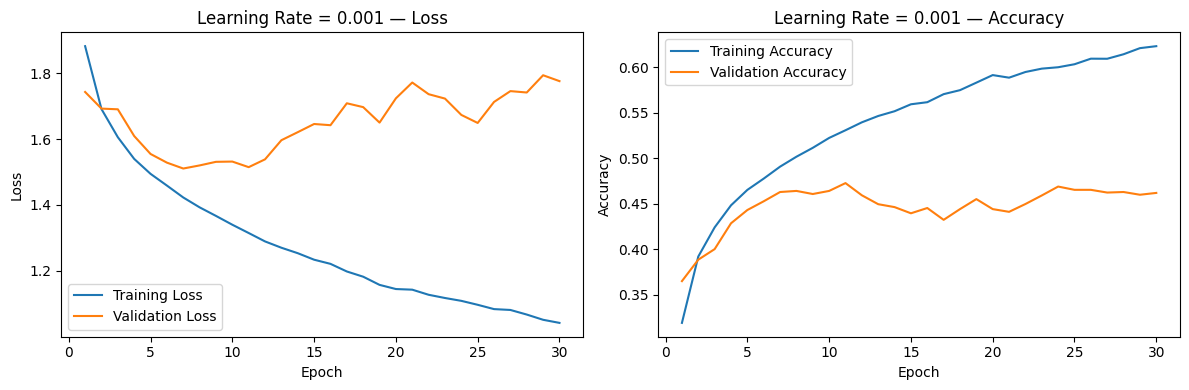

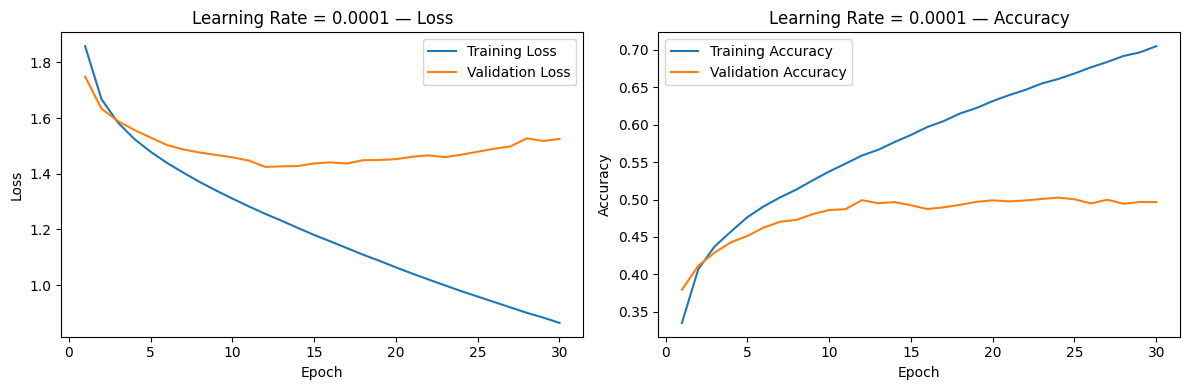

In [ ]:
# Individual Training vs Validation curves per learning rate (reuses plot_history from Part 6)
for lr, history in lr_histories.items():
    plot_history(history, f"Learning Rate = {lr}")


In [ ]:
lr_summary_rows = []
for lr, history in lr_histories.items():
    lr_summary_rows.append({
        "Learning Rate": lr,
        "Best Train Acc.": round(max(history.history['accuracy']), 4),
        "Best Val Acc.": round(max(history.history['val_accuracy']), 4),
        "Min Val Loss": round(min(history.history['val_loss']), 4),
    })

lr_summary_df = pd.DataFrame(lr_summary_rows).sort_values("Best Val Acc.", ascending=False).reset_index(drop=True)
lr_summary_df


,Learning Rate,Best Train Acc.,Best Val Acc.,Min Val Loss
0,0.0001,0.7050,0.5026,1.4245
1,0.0010,0.6232,0.4726,1.5106
2,0.0100,0.2725,0.2740,1.9199


In [ ]:
# Automatically select the learning rate with the highest validation accuracy actually observed
BEST_LR = lr_summary_df.loc[0, "Learning Rate"]
print("Best learning rate selected (highest validation accuracy):", BEST_LR)


Best learning rate selected (highest validation accuracy): 0.0001


**Which learning rate is most appropriate for this model, and what evidence supports the decision?**

The learning rate 0.0001 was the most appropriate for the selected Medium Network. It achieved the highest validation accuracy of 0.5026 and the lowest validation loss among the tested rates. A learning rate of 0.01 was too large and produced poor, unstable performance, while 0.001 performed reasonably but was still worse than 0.0001. Therefore, 0.0001 provided the best balance between stable convergence and validation performance.

---
## Part 10 — Batch Size Experiment

Using `BEST_LR` from Part 9, we compare batch sizes **16, 32, 64**. Architecture, optimizer, data, seed, and epoch budget stay fixed — only the batch size changes.

In [ ]:
batch_sizes_to_test = [16, 32, 64]
BATCH_EPOCHS = COMMON_EPOCHS

batch_histories = {}

for bs in batch_sizes_to_test:
    print(f"\n--- Training with batch size = {bs} (LR={BEST_LR}) ---")
    model = build_selected_model(learning_rate=BEST_LR, optimizer_name="adam")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=BATCH_EPOCHS,
        batch_size=bs,
        verbose=1
    )
    batch_histories[bs] = history



--- Training with batch size = 16 (LR=0.0001) ---
Epoch 1/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.3358 - loss: 1.8405 - val_accuracy: 0.4018 - val_loss: 1.6758
Epoch 2/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 73s 26ms/step - accuracy: 0.4109 - loss: 1.6455 - val_accuracy: 0.4334 - val_loss: 1.5966
Epoch 3/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.4436 - loss: 1.5567 - val_accuracy: 0.4544 - val_loss: 1.5435
Epoch 4/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 78s 28ms/step - accuracy: 0.4664 - loss: 1.4932 - val_accuracy: 0.4636 - val_loss: 1.5163
Epoch 5/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 75s 27ms/step - accuracy: 0.4850 - loss: 1.4431 - val_accuracy: 0.4716 - val_loss: 1.5017
Epoch 6/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 75s 27ms/step - accuracy: 0.5013 - loss: 1.3975 - val_accuracy: 0.4762 - val_loss: 1.4928
Epoch 7/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.5165 - loss: 1.3568 - val_accuracy: 0.4762 - val_loss: 1.4840
Epoch 8/30
2813/2813 ━━━━

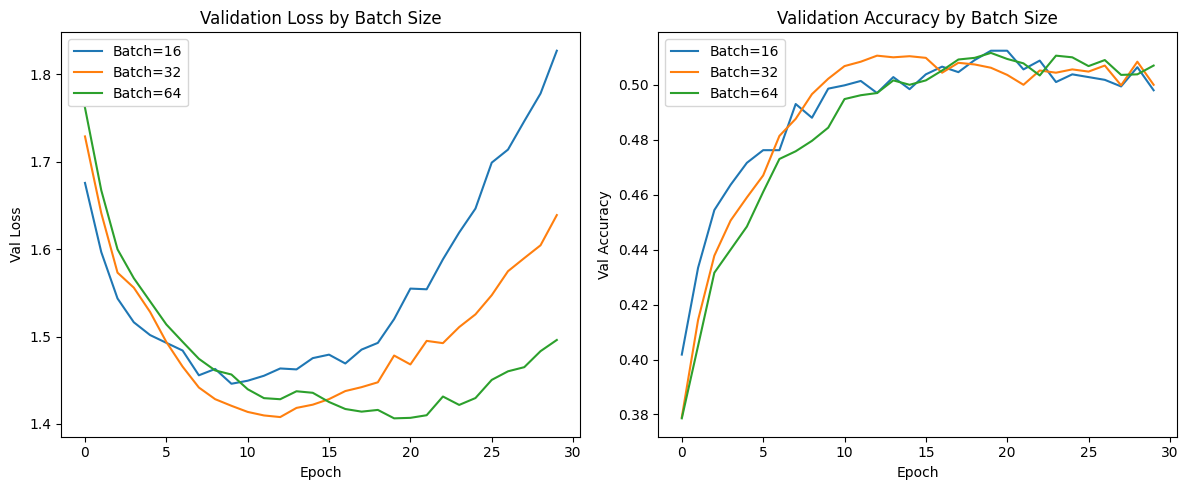

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for bs, history in batch_histories.items():
    plt.plot(history.history['val_loss'], label=f'Batch={bs}')
plt.title('Validation Loss by Batch Size')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()

plt.subplot(1, 2, 2)
for bs, history in batch_histories.items():
    plt.plot(history.history['val_accuracy'], label=f'Batch={bs}')
plt.title('Validation Accuracy by Batch Size')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
batch_summary_rows = []
for bs, history in batch_histories.items():
    batch_summary_rows.append({
        "Batch Size": bs,
        "Best Train Acc.": round(max(history.history['accuracy']), 4),
        "Best Val Acc.": round(max(history.history['val_accuracy']), 4),
        "Min Val Loss": round(min(history.history['val_loss']), 4),
    })

batch_summary_df = pd.DataFrame(batch_summary_rows).sort_values("Best Val Acc.", ascending=False).reset_index(drop=True)
batch_summary_df


,Batch Size,Best Train Acc.,Best Val Acc.,Min Val Loss
0,16,0.7762,0.5124,1.4460
1,64,0.7135,0.5116,1.4064
2,32,0.7452,0.5106,1.4079


In [ ]:
# Automatically select the batch size with the highest validation accuracy actually observed
BEST_BATCH_SIZE = int(batch_summary_df.loc[0, "Batch Size"])
print("Best batch size selected (highest validation accuracy):", BEST_BATCH_SIZE)


Best batch size selected (highest validation accuracy): 16


**Which batch size produced the best result? Did increasing batch size automatically improve the model? What effect did batch size have on the learning curves?**

Batch size 16 produced the highest validation accuracy of 0.5124. Increasing the batch size did not automatically improve performance, because batch sizes 32 and 64 achieved slightly lower validation accuracy. The differences were small, but batch size 16 provided the best validation result. Smaller batches showed slightly more variation in the learning curves because the model updated its weights more frequently.

---
## Part 11 — Optimizer Experiment

We compare **Adam** (at `BEST_LR`) against **SGD with momentum** (at a higher learning rate, since SGD typically needs a larger step size than Adam). Architecture, data, seed, and `BEST_BATCH_SIZE` stay fixed.

In [31]:
optimizer_configs = {
    "Adam": {"optimizer_name": "adam", "learning_rate": BEST_LR, "momentum": 0.0},
    "SGD":  {"optimizer_name": "sgd",  "learning_rate": 0.01,   "momentum": 0.9},
}
OPTIMIZER_EPOCHS = COMMON_EPOCHS

optimizer_histories = {}

for opt_label, cfg in optimizer_configs.items():
    print(f"\n--- Training with optimizer = {opt_label} (LR={cfg['learning_rate']}) ---")
    model = build_selected_model(
        learning_rate=cfg["learning_rate"],
        optimizer_name=cfg["optimizer_name"],
        momentum=cfg["momentum"],
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=OPTIMIZER_EPOCHS,
        batch_size=BEST_BATCH_SIZE,
        verbose=1
    )
    optimizer_histories[opt_label] = history



--- Training with optimizer = Adam (LR=0.0001) ---
Epoch 1/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 71s 25ms/step - accuracy: 0.3324 - loss: 1.8525 - val_accuracy: 0.3966 - val_loss: 1.6880
Epoch 2/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step - accuracy: 0.4087 - loss: 1.6572 - val_accuracy: 0.4264 - val_loss: 1.6132
Epoch 3/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 79s 24ms/step - accuracy: 0.4392 - loss: 1.5681 - val_accuracy: 0.4410 - val_loss: 1.5649
Epoch 4/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - accuracy: 0.4619 - loss: 1.5053 - val_accuracy: 0.4574 - val_loss: 1.5257
Epoch 5/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 82s 24ms/step - accuracy: 0.4819 - loss: 1.4534 - val_accuracy: 0.4708 - val_loss: 1.4957
Epoch 6/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.4992 - loss: 1.4080 - val_accuracy: 0.4772 - val_loss: 1.4738
Epoch 7/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.5130 - loss: 1.3678 - val_accuracy: 0.4800 - val_loss: 1.4686
Epoch 8/30
2813/2813 ━━━

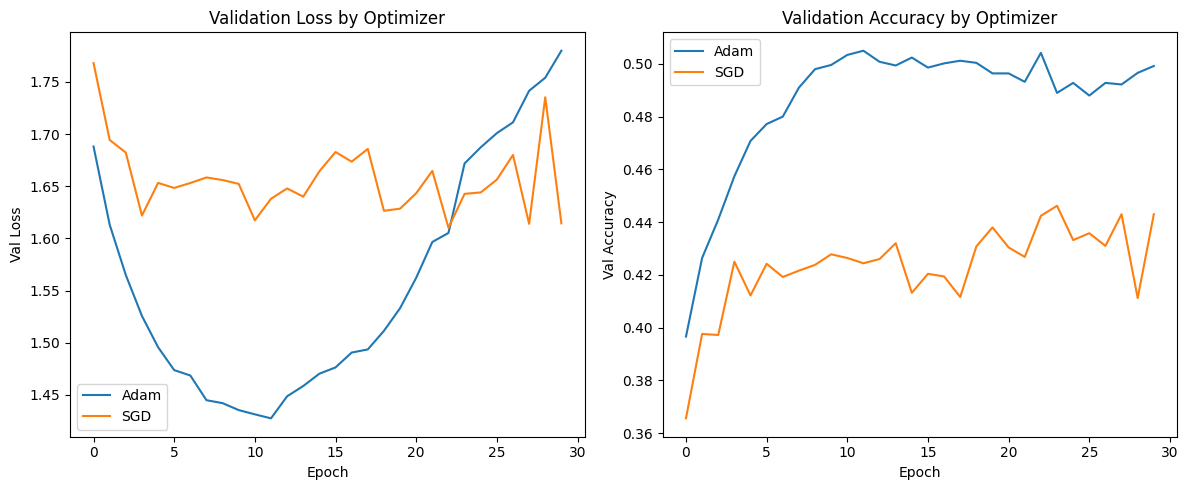

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for opt_label, history in optimizer_histories.items():
    plt.plot(history.history['val_loss'], label=opt_label)
plt.title('Validation Loss by Optimizer')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()

plt.subplot(1, 2, 2)
for opt_label, history in optimizer_histories.items():
    plt.plot(history.history['val_accuracy'], label=opt_label)
plt.title('Validation Accuracy by Optimizer')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()

plt.tight_layout()
plt.show()


In [33]:
optimizer_summary_rows = []
for opt_label, history in optimizer_histories.items():
    optimizer_summary_rows.append({
        "Optimizer": opt_label,
        "Learning Rate": optimizer_configs[opt_label]["learning_rate"],
        "Best Train Acc.": round(max(history.history['accuracy']), 4),
        "Best Val Acc.": round(max(history.history['val_accuracy']), 4),
        "Min Val Loss": round(min(history.history['val_loss']), 4),
    })

optimizer_summary_df = pd.DataFrame(optimizer_summary_rows).sort_values("Best Val Acc.", ascending=False).reset_index(drop=True)
optimizer_summary_df


,Optimizer,Learning Rate,Best Train Acc.,Best Val Acc.,Min Val Loss
0,Adam,0.0001,0.7703,0.5050,1.4276
1,SGD,0.0100,0.4952,0.4462,1.6102


In [34]:
# Automatically select the optimizer with the highest validation accuracy actually observed
best_opt_label = optimizer_summary_df.loc[0, "Optimizer"]
BEST_OPTIMIZER_NAME = optimizer_configs[best_opt_label]["optimizer_name"]
BEST_OPTIMIZER_LR = optimizer_configs[best_opt_label]["learning_rate"]
BEST_OPTIMIZER_MOMENTUM = optimizer_configs[best_opt_label]["momentum"]

print("Best optimizer selected:", best_opt_label,
      f"(lr={BEST_OPTIMIZER_LR}, momentum={BEST_OPTIMIZER_MOMENTUM})")


Best optimizer selected: Adam (lr=0.0001, momentum=0.0)


**Which optimizer would you select, and why?**

Recall: backpropagation computes the gradients; the optimizer determines how those gradients are turned into weight updates (step size, momentum, adaptive per-parameter rates, etc.).

Adam was selected because it converged faster and achieved better validation performance than SGD. Adam reached a best validation accuracy of 0.5050, while SGD achieved 0.4462. Adam also showed more effective convergence within the same training budget, so it was selected for the following experiments.

## Part 12 — Regularization Experiments

The purpose of this section is to investigate whether regularization can improve the generalization of the selected **Medium Dense Neural Network**.

All experiments use the optimized settings identified in Parts 9–11:

- **Architecture:** Medium — [512, 256, 128]
- **Learning Rate:** 0.0001
- **Batch Size:** 16
- **Optimizer:** Adam

To ensure a fair comparison, each experiment starts with a freshly initialized model while keeping all other settings unchanged.

Four configurations are evaluated:

1. Baseline — no additional regularization
2. Dropout — rate = 0.3
3. Early Stopping — monitoring validation loss and restoring the best weights
4. L2 Regularization — λ = 0.0001

The techniques are evaluated using training performance, validation performance, generalization gap, and learning curves.

In [35]:
def build_flexible_model(hidden_units=None, learning_rate=None, optimizer_name=None, momentum=None,
                          dropout_rate=0.0, l2_lambda=0.0, use_batchnorm=False):
    """Generic builder for the SELECTED_ARCHITECTURE's hidden-layer widths, with optional
    Dropout, L2 regularization, and Batch Normalization for the controlled experiments in
    Parts 12-15. The architecture itself (number & width of hidden layers) is NOT changed
    by this function - only the regularization / stability options are."""
    tf.random.set_seed(SEED)

    if hidden_units is None:
        hidden_units = _ARCH_HIDDEN_UNITS[SELECTED_ARCHITECTURE]
    if learning_rate is None:
        learning_rate = BEST_OPTIMIZER_LR
    if optimizer_name is None:
        optimizer_name = BEST_OPTIMIZER_NAME
    if momentum is None:
        momentum = BEST_OPTIMIZER_MOMENTUM if optimizer_name == "sgd" else 0.0

    regularizer = keras.regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    model = keras.Sequential(name=f"{SELECTED_ARCHITECTURE.capitalize()}_Flexible")
    model.add(layers.Input(shape=(3072,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu', kernel_regularizer=regularizer))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    else:
        raise ValueError(f"Unknown optimizer_name: {optimizer_name}")

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


REG_EPOCHS = COMMON_EPOCHS
FINAL_DROPOUT_RATE_TESTED = 0.3
FINAL_L2_LAMBDA_TESTED = 1e-4


In [36]:
# Experiment A - Baseline (no additional regularization)
print("Training Regularization Baseline...")
reg_baseline_model = build_flexible_model()
reg_baseline_history = reg_baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=1
)


Training Regularization Baseline...
Epoch 1/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 73s 25ms/step - accuracy: 0.3379 - loss: 1.8383 - val_accuracy: 0.4034 - val_loss: 1.6755
Epoch 2/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step - accuracy: 0.4114 - loss: 1.6478 - val_accuracy: 0.4294 - val_loss: 1.5983
Epoch 3/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 85s 26ms/step - accuracy: 0.4434 - loss: 1.5588 - val_accuracy: 0.4440 - val_loss: 1.5555
Epoch 4/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 71s 25ms/step - accuracy: 0.4661 - loss: 1.4948 - val_accuracy: 0.4610 - val_loss: 1.5201
Epoch 5/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 69s 25ms/step - accuracy: 0.4857 - loss: 1.4449 - val_accuracy: 0.4674 - val_loss: 1.5000
Epoch 6/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 75s 27ms/step - accuracy: 0.5011 - loss: 1.3994 - val_accuracy: 0.4798 - val_loss: 1.4900
Epoch 7/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step - accuracy: 0.5189 - loss: 1.3564 - val_accuracy: 0.4878 - val_loss: 1.4638
Epoch 8/30
2813/2813 ━━━━━━━━━━━━━━━━━━━

### Experiment A — Regularization Baseline

First, the optimized model is trained without any additional regularization. This provides the reference point for evaluating whether Dropout, Early Stopping, or L2 Regularization improves generalization.

In [37]:
# Experiment B - Dropout
print("Training with Dropout (rate=0.3)...")
reg_dropout_model = build_flexible_model(dropout_rate=FINAL_DROPOUT_RATE_TESTED)
reg_dropout_history = reg_dropout_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=1
)


Training with Dropout (rate=0.3)...
Epoch 1/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 72s 25ms/step - accuracy: 0.2331 - loss: 2.0647 - val_accuracy: 0.3470 - val_loss: 1.8450
Epoch 2/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 81s 24ms/step - accuracy: 0.3119 - loss: 1.8968 - val_accuracy: 0.3742 - val_loss: 1.7611
Epoch 3/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 69s 25ms/step - accuracy: 0.3438 - loss: 1.8190 - val_accuracy: 0.3840 - val_loss: 1.7193
Epoch 4/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - accuracy: 0.3635 - loss: 1.7733 - val_accuracy: 0.4146 - val_loss: 1.6640
Epoch 5/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.3788 - loss: 1.7348 - val_accuracy: 0.4128 - val_loss: 1.6386
Epoch 6/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 82s 24ms/step - accuracy: 0.3945 - loss: 1.7001 - val_accuracy: 0.4398 - val_loss: 1.6005
Epoch 7/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step - accuracy: 0.4035 - loss: 1.6695 - val_accuracy: 0.4280 - val_loss: 1.5908
Epoch 8/30
2813/2813 ━━━━━━━━━━━━━━━━━━━

### Experiment B — Dropout

Dropout randomly disables a fraction of neurons during training, reducing reliance on specific neurons and potentially limiting overfitting.

A Dropout rate of **0.3** is tested while keeping the architecture and all other training settings unchanged.

In [60]:
# Experiment C - Early Stopping (monitors val_loss, restores best weights)
# Early Stopping monitors validation loss and may stop before the 30-epoch maximum.
EARLY_STOP_MAX_EPOCHS = 30

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Training with Early Stopping...")
reg_earlystop_model = build_flexible_model()
reg_earlystop_history = reg_earlystop_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EARLY_STOP_MAX_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[early_stop_cb],
    verbose=1
)


Training with Early Stopping...
Epoch 1/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 69s 24ms/step - accuracy: 0.3357 - loss: 1.8409 - val_accuracy: 0.4032 - val_loss: 1.6832
Epoch 2/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.4131 - loss: 1.6491 - val_accuracy: 0.4360 - val_loss: 1.5991
Epoch 3/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - accuracy: 0.4431 - loss: 1.5602 - val_accuracy: 0.4408 - val_loss: 1.5675
Epoch 4/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 66s 23ms/step - accuracy: 0.4674 - loss: 1.4959 - val_accuracy: 0.4564 - val_loss: 1.5374
Epoch 5/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 85s 25ms/step - accuracy: 0.4860 - loss: 1.4448 - val_accuracy: 0.4600 - val_loss: 1.5119
Epoch 6/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 66s 23ms/step - accuracy: 0.5000 - loss: 1.3999 - val_accuracy: 0.4758 - val_loss: 1.4776
Epoch 7/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 66s 23ms/step - accuracy: 0.5166 - loss: 1.3574 - val_accuracy: 0.4868 - val_loss: 1.4532
Epoch 8/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 65

### Experiment C — Early Stopping

Early Stopping monitors **validation loss** during training and stops when validation performance no longer improves.

`restore_best_weights=True` ensures that the model returns to the weights from the epoch with the best validation loss rather than keeping the weights from the final epoch.

In [61]:
# Experiment D - L2 Regularization
print("Training with L2 Regularization (lambda=1e-4)...")
reg_l2_model = build_flexible_model(l2_lambda=FINAL_L2_LAMBDA_TESTED)
reg_l2_history = reg_l2_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=1
)


Training with L2 Regularization (lambda=1e-4)...
Epoch 1/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 90s 31ms/step - accuracy: 0.3339 - loss: 1.9556 - val_accuracy: 0.4018 - val_loss: 1.7708
Epoch 2/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 86s 31ms/step - accuracy: 0.4084 - loss: 1.7403 - val_accuracy: 0.4276 - val_loss: 1.6759
Epoch 3/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 85s 30ms/step - accuracy: 0.4422 - loss: 1.6410 - val_accuracy: 0.4478 - val_loss: 1.6264
Epoch 4/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 141s 30ms/step - accuracy: 0.4661 - loss: 1.5714 - val_accuracy: 0.4684 - val_loss: 1.5834
Epoch 5/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.4828 - loss: 1.5205 - val_accuracy: 0.4636 - val_loss: 1.5829
Epoch 6/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 142s 30ms/step - accuracy: 0.4988 - loss: 1.4790 - val_accuracy: 0.4794 - val_loss: 1.5635
Epoch 7/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 85s 30ms/step - accuracy: 0.5139 - loss: 1.4410 - val_accuracy: 0.4874 - val_loss: 1.5424
Epoch 8/30
2813/2813 ━━━━

### Experiment D — L2 Regularization

L2 Regularization adds a penalty for large model weights to the loss function. This encourages smaller weights and may reduce overfitting.

An L2 strength of **λ = 0.0001** is tested while keeping the remaining settings unchanged.

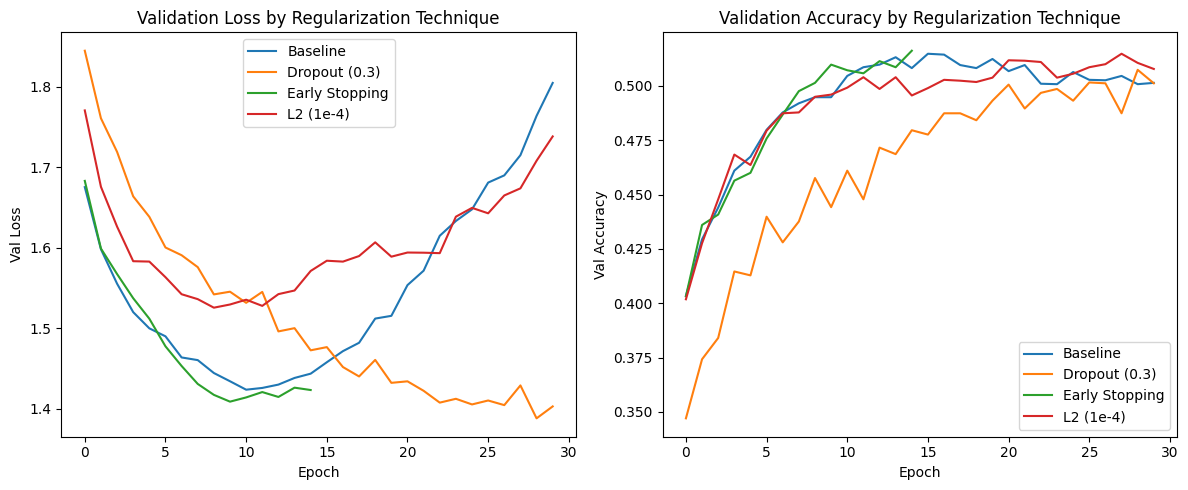

In [64]:
# Compare all four regularization experiments
plt.figure(figsize=(12, 5))

reg_histories_map = {
    "Baseline": reg_baseline_history,
    "Dropout (0.3)": reg_dropout_history,
    "Early Stopping": reg_earlystop_history,
    "L2 (1e-4)": reg_l2_history,
}

plt.subplot(1, 2, 1)
for label, history in reg_histories_map.items():
    plt.plot(history.history['val_loss'], label=label)
plt.title('Validation Loss by Regularization Technique')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()

plt.subplot(1, 2, 2)
for label, history in reg_histories_map.items():
    plt.plot(history.history['val_accuracy'], label=label)
plt.title('Validation Accuracy by Regularization Technique')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()

plt.tight_layout()
plt.show()


In [65]:
def summarize_reg(name, history):
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    best_train_acc = max(train_acc)
    best_val_acc = max(val_acc)
    min_val_loss = min(history.history['val_loss'])
    gen_gap = round(best_train_acc - best_val_acc, 4)
    return {
        "Experiment": name,
        "Best Train Acc.": round(best_train_acc, 4),
        "Best Val Acc.": round(best_val_acc, 4),
        "Min Val Loss": round(min_val_loss, 4),
        "Generalization Gap (Train-Val Acc.)": gen_gap,
        "Epochs Run": len(train_acc),
    }

reg_comparison_df = pd.DataFrame([
    summarize_reg(label, history) for label, history in reg_histories_map.items()
])
reg_comparison_df


,Experiment,Best Train Acc.,Best Val Acc.,Min Val Loss,Generalization Gap (Train-Val Acc.),Epochs Run
0,Baseline,0.7725,0.5148,1.4237,0.2577,30
1,Dropout (0.3),0.4984,0.5074,1.3881,-0.0090,30
2,Early Stopping,0.6221,0.5162,1.4088,0.1059,15
3,L2 (1e-4),0.7381,0.5148,1.5256,0.2233,30


### Regularization Results & Interpretation

The regularization experiments showed that adding a regularization technique did **not automatically improve validation performance**.

- **Baseline:** Best Validation Accuracy = **0.5148**
- **Dropout (0.3):** Best Validation Accuracy = **0.5074**
- **Early Stopping:** Best Validation Accuracy = **0.5162**
- **L2 Regularization (λ = 1e-4):** Best Validation Accuracy = **0.5148**

Among the tested techniques, **Early Stopping achieved the highest validation accuracy (0.5162)**, slightly outperforming the unregularized baseline (0.5148).

Dropout reduced validation performance to 0.5074, suggesting that a dropout rate of 0.3 was not beneficial for this model. L2 Regularization produced approximately the same best validation accuracy as the baseline and therefore did not provide a measurable improvement.

Overall, **Early Stopping was the most useful regularization technique in this experiment**, although the improvement over the baseline was small. These results demonstrate why regularization techniques should be selected based on experimental evidence rather than included automatically.

---
## Part 13 — Training Stability Experiment (Batch Normalization)

We add `BatchNormalization()` after each hidden Dense layer and compare it against the exact same architecture without it. The "without BatchNorm" baseline reuses `reg_baseline_history` from Part 12 (same architecture, same LR/batch/optimizer, no other regularization) — no need to retrain that configuration a second time.

In [43]:
print("Training WITH Batch Normalization...")
bn_on_model = build_flexible_model(use_batchnorm=True)
bn_on_history = bn_on_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=1
)

# "Without BatchNorm" reuses the Part 12 baseline - identical architecture/LR/batch/optimizer,
# the ONLY difference from bn_on_history is the presence of BatchNormalization layers.
bn_off_history = reg_baseline_history


Training WITH Batch Normalization...
Epoch 1/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 77s 26ms/step - accuracy: 0.3432 - loss: 1.8720 - val_accuracy: 0.3610 - val_loss: 1.8111
Epoch 2/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 72s 26ms/step - accuracy: 0.4157 - loss: 1.6585 - val_accuracy: 0.4108 - val_loss: 1.6713
Epoch 3/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - accuracy: 0.4499 - loss: 1.5608 - val_accuracy: 0.4362 - val_loss: 1.6115
Epoch 4/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - accuracy: 0.4729 - loss: 1.4970 - val_accuracy: 0.4338 - val_loss: 1.6007
Epoch 5/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 89s 27ms/step - accuracy: 0.4974 - loss: 1.4338 - val_accuracy: 0.4632 - val_loss: 1.5391
Epoch 6/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 73s 26ms/step - accuracy: 0.5115 - loss: 1.3889 - val_accuracy: 0.4706 - val_loss: 1.5472
Epoch 7/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 69s 24ms/step - accuracy: 0.5313 - loss: 1.3388 - val_accuracy: 0.4396 - val_loss: 1.6398
Epoch 8/30
2813/2813 ━━━━━━━━━━━━━━━━━━

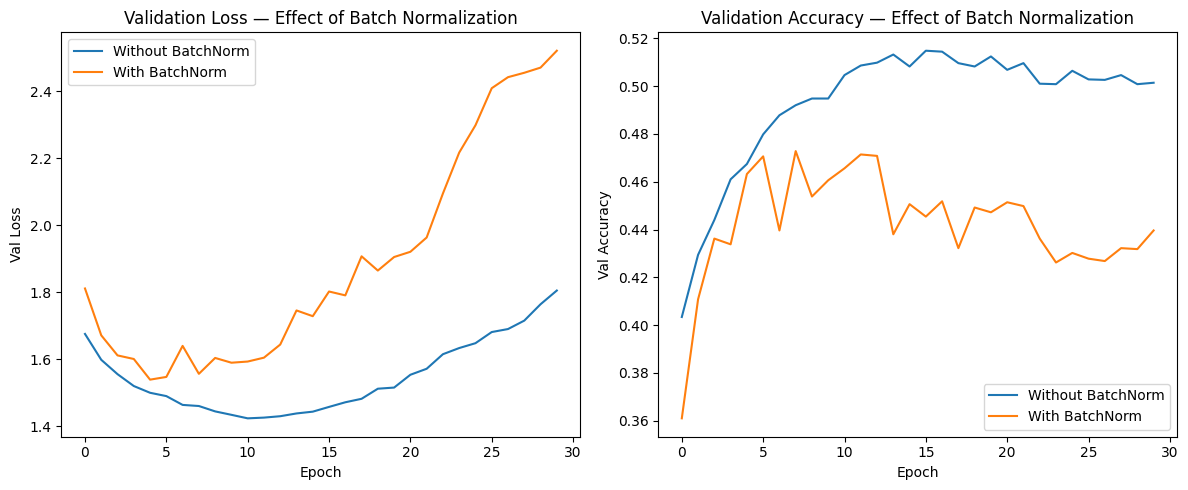

In [44]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(bn_off_history.history['val_loss'], label='Without BatchNorm')
plt.plot(bn_on_history.history['val_loss'], label='With BatchNorm')
plt.title('Validation Loss — Effect of Batch Normalization')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bn_off_history.history['val_accuracy'], label='Without BatchNorm')
plt.plot(bn_on_history.history['val_accuracy'], label='With BatchNorm')
plt.title('Validation Accuracy — Effect of Batch Normalization')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()

plt.tight_layout()
plt.show()


Training Deep architecture WITHOUT Batch Normalization...
Epoch 1/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - accuracy: 0.3097 - loss: 1.9080 - val_accuracy: 0.3752 - val_loss: 1.7363
Epoch 2/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 65s 23ms/step - accuracy: 0.3874 - loss: 1.7071 - val_accuracy: 0.4110 - val_loss: 1.6563
Epoch 3/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 66s 23ms/step - accuracy: 0.4258 - loss: 1.6136 - val_accuracy: 0.4248 - val_loss: 1.6186
Epoch 4/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - accuracy: 0.4489 - loss: 1.5490 - val_accuracy: 0.4366 - val_loss: 1.6130
Epoch 5/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 82s 24ms/step - accuracy: 0.4666 - loss: 1.4981 - val_accuracy: 0.4534 - val_loss: 1.5576
Epoch 6/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 65s 23ms/step - accuracy: 0.4824 - loss: 1.4553 - val_accuracy: 0.4682 - val_loss: 1.5223
Epoch 7/30
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 65s 23ms/step - accuracy: 0.4983 - loss: 1.4148 - val_accuracy: 0.4760 - val_loss: 1.5041
Epoch 8/30
2813/28

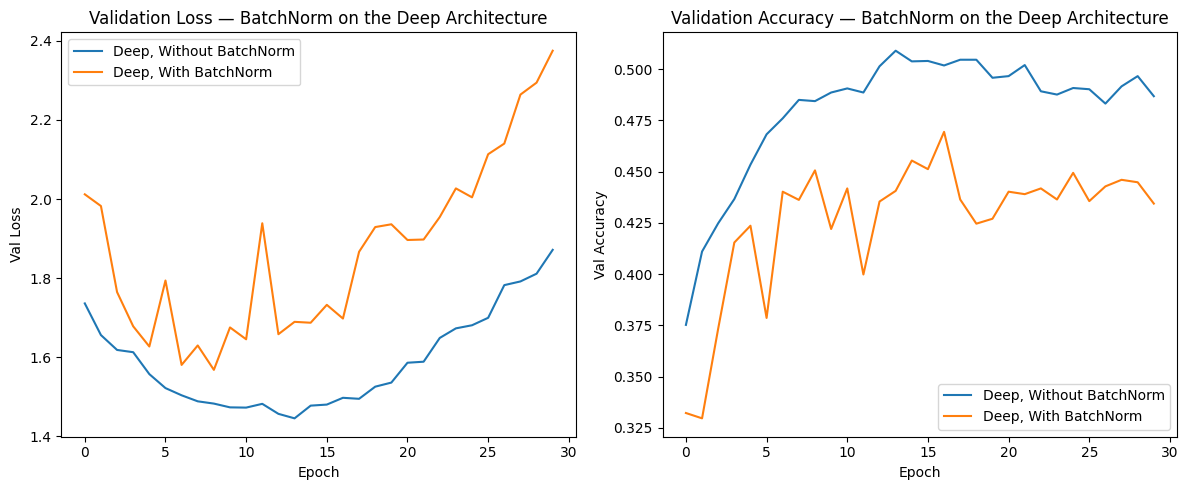

In [45]:
# Additional check: is the BatchNorm effect more noticeable on the Deep architecture
# specifically? We test BatchNorm on/off using the Deep hidden-layer widths directly,
# regardless of which architecture was selected in Part 8.
print("Training Deep architecture WITHOUT Batch Normalization...")
deep_bn_off_model = build_flexible_model(hidden_units=_ARCH_HIDDEN_UNITS["deep"], use_batchnorm=False)
deep_bn_off_history = deep_bn_off_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=REG_EPOCHS, batch_size=BEST_BATCH_SIZE, verbose=1
)

print("Training Deep architecture WITH Batch Normalization...")
deep_bn_on_model = build_flexible_model(hidden_units=_ARCH_HIDDEN_UNITS["deep"], use_batchnorm=True)
deep_bn_on_history = deep_bn_on_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=REG_EPOCHS, batch_size=BEST_BATCH_SIZE, verbose=1
)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(deep_bn_off_history.history['val_loss'], label='Deep, Without BatchNorm')
plt.plot(deep_bn_on_history.history['val_loss'], label='Deep, With BatchNorm')
plt.title('Validation Loss — BatchNorm on the Deep Architecture')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deep_bn_off_history.history['val_accuracy'], label='Deep, Without BatchNorm')
plt.plot(deep_bn_on_history.history['val_accuracy'], label='Deep, With BatchNorm')
plt.title('Validation Accuracy — BatchNorm on the Deep Architecture')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()
plt.tight_layout()
plt.show()


**Discussion (fill in after viewing the plots above):**

riate-shift / unstable activations, which BatchNorm is designed to address)?

Batch Normalization did not improve training stability or validation performance in this experiment. The model with Batch Normalization achieved lower validation accuracy and substantially higher validation loss than the same architecture without Batch Normalization. The learning curves were also more unstable. The additional experiment on the Deep Network showed a similar result, so Batch Normalization was not beneficial for this dataset and Dense architecture configuration and was not selected for the Final Model.


---
## Part 14 — Ablation Experiment

We isolate the effect of **one** technique from Parts 12–13 by comparing:
- **Model A** — with the technique
- **Model B** — without it (identical architecture, data, seed, optimizer, learning rate, batch size)

The technique compared is chosen automatically as whichever of {Dropout, Early Stopping, L2, Batch Normalization} produced the **highest validation accuracy** among the experiments already run — no retraining needed, since Parts 12–13 already isolated each one against the same baseline.

In [66]:
technique_results = {
    "Dropout": reg_dropout_history,
    "Early Stopping": reg_earlystop_history,
    "L2": reg_l2_history,
    "Batch Normalization": bn_on_history,
}

best_technique_name = max(
    technique_results,
    key=lambda name: max(technique_results[name].history['val_accuracy'])
)
print("Technique selected for the ablation experiment (highest validation accuracy so far):", best_technique_name)

ablation_with_history = technique_results[best_technique_name]     # Model A: with the technique
ablation_without_history = reg_baseline_history                     # Model B: identical setup, no added technique

# NOTE: both models used the exact same architecture, data, seed, optimizer, learning rate,
# and batch size (Part 12/13). The ONLY difference between them is `best_technique_name`.


Technique selected for the ablation experiment (highest validation accuracy so far): Early Stopping


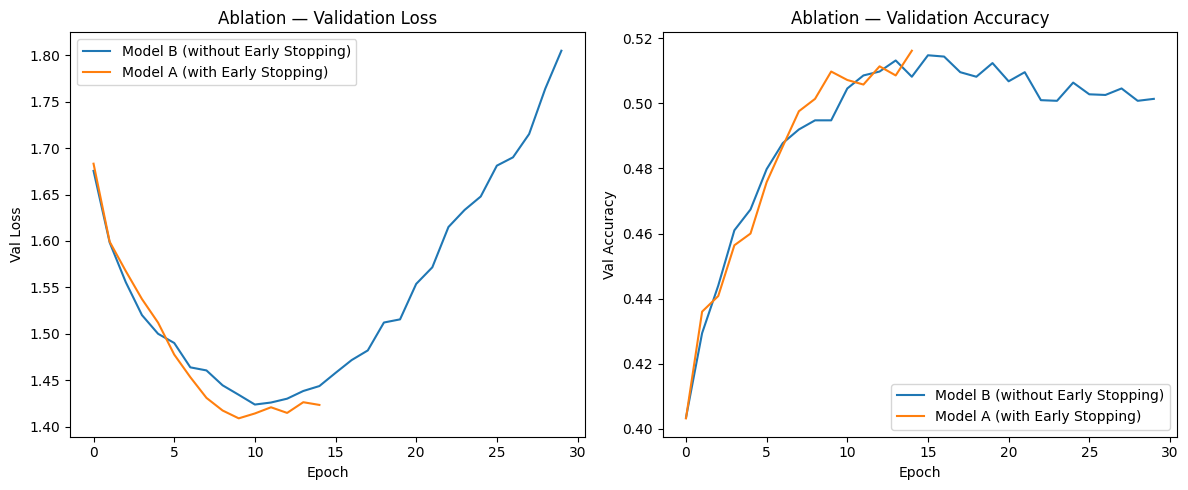

In [67]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ablation_without_history.history['val_loss'], label=f'Model B (without {best_technique_name})')
plt.plot(ablation_with_history.history['val_loss'], label=f'Model A (with {best_technique_name})')
plt.title('Ablation — Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ablation_without_history.history['val_accuracy'], label=f'Model B (without {best_technique_name})')
plt.plot(ablation_with_history.history['val_accuracy'], label=f'Model A (with {best_technique_name})')
plt.title('Ablation — Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()

plt.tight_layout()
plt.show()


In [68]:
ablation_df = pd.DataFrame([
    {
        "Model": f"A (with {best_technique_name})",
        "Best Train Acc.": round(max(ablation_with_history.history['accuracy']), 4),
        "Best Val Acc.": round(max(ablation_with_history.history['val_accuracy']), 4),
        "Min Val Loss": round(min(ablation_with_history.history['val_loss']), 4),
    },
    {
        "Model": f"B (without {best_technique_name})",
        "Best Train Acc.": round(max(ablation_without_history.history['accuracy']), 4),
        "Best Val Acc.": round(max(ablation_without_history.history['val_accuracy']), 4),
        "Min Val Loss": round(min(ablation_without_history.history['val_loss']), 4),
    },
])
ablation_df


,Model,Best Train Acc.,Best Val Acc.,Min Val Loss
0,A (with Early Stopping),0.6221,0.5162,1.4088
1,B (without Early Stopping),0.7725,0.5148,1.4237


**Did this component actually contribute to better performance or generalization?**



Early Stopping produced only a small improvement in validation performance compared with the baseline. The best validation accuracy increased slightly from 0.5148 to 0.5162, while the minimum validation loss decreased from 1.4237 to 1.4088. Therefore, the performance improvement was not substantial. However, Early Stopping was still useful because it stopped training before validation loss increased further, reducing unnecessary training and limiting overfitting.


---
## Part 15 — Build Your Final Model

The Final Model combines only the settings **supported by evidence** from Parts 9–13:
- Architecture: `SELECTED_ARCHITECTURE` (unchanged from Part 8)
- Learning rate & optimizer: `BEST_OPTIMIZER_LR` / `BEST_OPTIMIZER_NAME` (Parts 9 & 11)
- Batch size: `BEST_BATCH_SIZE` (Part 10)
- Dropout / L2 / Batch Normalization: included **only if** that specific experiment in Part 12–13 beat the Part 12 baseline's validation accuracy
- Early Stopping: included **only if** it beat the baseline's validation accuracy in Part 12

We do **not** include every technique automatically — each one is switched on independently, based on whether it actually helped.

In [70]:
def technique_beats_baseline(history, baseline_history=reg_baseline_history):
    return max(history.history['val_accuracy']) > max(baseline_history.history['val_accuracy'])

USE_DROPOUT = technique_beats_baseline(reg_dropout_history)
USE_L2 = technique_beats_baseline(reg_l2_history)
USE_BATCHNORM = technique_beats_baseline(bn_on_history)
USE_EARLY_STOPPING = technique_beats_baseline(reg_earlystop_history)

FINAL_DROPOUT_RATE = FINAL_DROPOUT_RATE_TESTED if USE_DROPOUT else 0.0
FINAL_L2_LAMBDA = FINAL_L2_LAMBDA_TESTED if USE_L2 else 0.0

print("Techniques selected for the Final Model, based on Part 12-13 evidence vs the baseline:")
print(f"  Dropout ({FINAL_DROPOUT_RATE_TESTED}):  {USE_DROPOUT}")
print(f"  L2 ({FINAL_L2_LAMBDA_TESTED}):          {USE_L2}")
print(f"  Batch Normalization:      {USE_BATCHNORM}")
print(f"  Early Stopping:           {USE_EARLY_STOPPING}")


Techniques selected for the Final Model, based on Part 12-13 evidence vs the baseline:
  Dropout (0.3):  False
  L2 (0.0001):          False
  Batch Normalization:      False
  Early Stopping:           True


In [71]:
final_model = build_flexible_model(
    learning_rate=BEST_OPTIMIZER_LR,
    optimizer_name=BEST_OPTIMIZER_NAME,
    momentum=BEST_OPTIMIZER_MOMENTUM,
    dropout_rate=FINAL_DROPOUT_RATE,
    l2_lambda=FINAL_L2_LAMBDA,
    use_batchnorm=USE_BATCHNORM,
)
final_model._name = "Final_Optimized_Network"
final_model.summary()

print("\nFinal configuration:")
print("  Architecture:        ", SELECTED_ARCHITECTURE, _ARCH_HIDDEN_UNITS[SELECTED_ARCHITECTURE])
print("  Optimizer:            ", BEST_OPTIMIZER_NAME)
print("  Learning Rate:        ", BEST_OPTIMIZER_LR)
print("  Batch Size:           ", BEST_BATCH_SIZE)
print("  Dropout:              ", f"{FINAL_DROPOUT_RATE} " + ("(enabled)" if USE_DROPOUT else "(disabled)"))
print("  L2 lambda:            ", f"{FINAL_L2_LAMBDA} " + ("(enabled)" if USE_L2 else "(disabled)"))
print("  Batch Normalization:  ", USE_BATCHNORM)
print("  Early Stopping:       ", USE_EARLY_STOPPING)
print("  Trainable parameters: ", final_model.count_params())


Model: "Medium_Flexible"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_108 (Dense)               │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


Final configuration:
  Architecture:         medium [512, 256, 128]
  Optimizer:             adam
  Learning Rate:         0.0001
  Batch Size:            16
  Dropout:               0.0 (disabled)
  L2 lambda:             0.0 (disabled)
  Batch Normalization:   False
  Early Stopping:        True
  Trainable parameters:  1738890


In [72]:
FINAL_EPOCHS = 60 if USE_EARLY_STOPPING else COMMON_EPOCHS
final_callbacks = []
if USE_EARLY_STOPPING:
    final_callbacks.append(
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    )

print("Training the Final Optimized Model...")
final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=final_callbacks,
    verbose=1
)


Training the Final Optimized Model...
Epoch 1/60
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 73s 25ms/step - accuracy: 0.3354 - loss: 1.8425 - val_accuracy: 0.3962 - val_loss: 1.6824
Epoch 2/60
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 78s 24ms/step - accuracy: 0.4133 - loss: 1.6472 - val_accuracy: 0.4378 - val_loss: 1.5943
Epoch 3/60
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 66s 23ms/step - accuracy: 0.4442 - loss: 1.5600 - val_accuracy: 0.4464 - val_loss: 1.5574
Epoch 4/60
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 83s 24ms/step - accuracy: 0.4664 - loss: 1.4986 - val_accuracy: 0.4556 - val_loss: 1.5339
Epoch 5/60
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - accuracy: 0.4841 - loss: 1.4469 - val_accuracy: 0.4676 - val_loss: 1.5123
Epoch 6/60
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 82s 24ms/step - accuracy: 0.5017 - loss: 1.4021 - val_accuracy: 0.4714 - val_loss: 1.5012
Epoch 7/60
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.5153 - loss: 1.3582 - val_accuracy: 0.4786 - val_loss: 1.4856
Epoch 8/60
2813/2813 ━━━━━━━━━━━━━━━━━

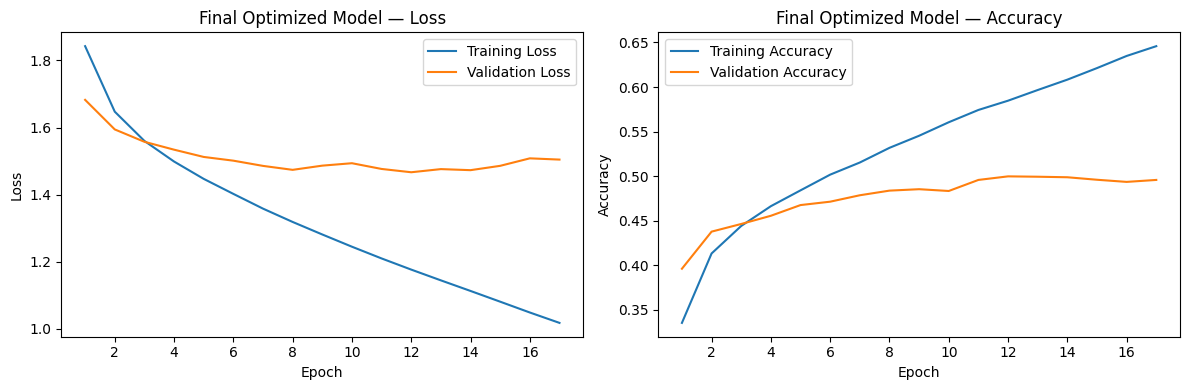

In [74]:
plot_history(final_history, "Final Optimized Model")


In [75]:
best_val_acc = max(final_history.history['val_accuracy'])
best_val_acc

0.4997999966144562

**Final Model summary (fill in the trainable-parameter count from the cell above):**

- Final architecture: medium [512, 256, 128]
- Trainable parameters: 1,738,890
- Best validation accuracy achieved: 0.4998 (49.98%)


---
## Part 16 — Final Test Evaluation

Only now — after the Final Model has been fully selected and trained — do we touch the Test Set (`X_test`, `y_test`) for the first time since Part 2. **No further tuning happens after this point.**

In [76]:
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss:     1.4501
Test Accuracy: 0.4962


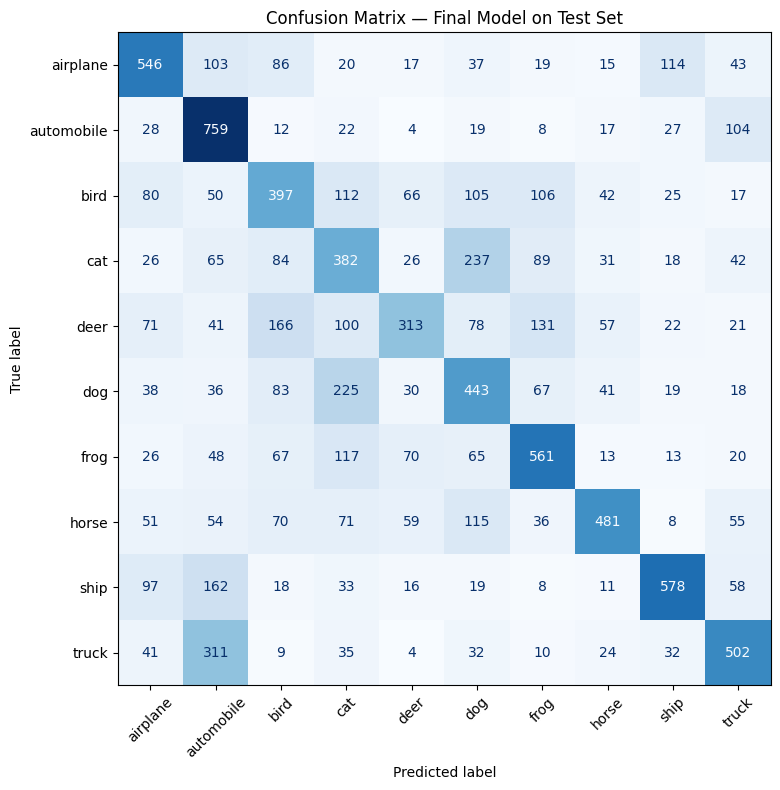

In [77]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred_probs = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Final Model on Test Set")
plt.tight_layout()
plt.show()


In [78]:
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


              precision    recall  f1-score   support

    airplane     0.5438    0.5460    0.5449      1000
  automobile     0.4659    0.7590    0.5774      1000
        bird     0.4002    0.3970    0.3986      1000
         cat     0.3420    0.3820    0.3609      1000
        deer     0.5174    0.3130    0.3900      1000
         dog     0.3852    0.4430    0.4121      1000
        frog     0.5420    0.5610    0.5514      1000
       horse     0.6571    0.4810    0.5554      1000
        ship     0.6752    0.5780    0.6228      1000
       truck     0.5705    0.5020    0.5340      1000

    accuracy                         0.4962     10000
   macro avg     0.5099    0.4962    0.4948     10000
weighted avg     0.5099    0.4962    0.4948     10000



**Test Set results (fill in after running the cells above):**



- Test Loss: 1.4501
- Test Accuracy: 0.4962 (49.62%)
- Overall Precision / Recall / F1 (macro avg): 0.5099 / 0.4962 / 0.4948


---
## Part 17 — Error Analysis

A single accuracy number isn't the full story. We look at which classes the Final Model handles well, which it struggles with, and what it confuses most often.

In [79]:
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, digits=4)
per_class_f1 = {cls: report_dict[cls]['f1-score'] for cls in class_names}

per_class_df = (
    pd.DataFrame.from_dict(per_class_f1, orient='index', columns=['F1-score'])
    .sort_values('F1-score', ascending=False)
)
per_class_df


,F1-score
ship,0.622845
automobile,0.577406
horse,0.555427
frog,0.551351
airplane,0.544910
truck,0.534043
dog,0.412093
bird,0.398594
deer,0.390031
cat,0.360888


In [80]:
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)

confused_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_no_diag[i, j] > 0:
            confused_pairs.append((class_names[i], class_names[j], int(cm_no_diag[i, j])))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
top_confused_df = pd.DataFrame(confused_pairs[:10], columns=["True Class", "Predicted Class", "Count"])
top_confused_df


,True Class,Predicted Class,Count
0,truck,automobile,311
1,cat,dog,237
2,dog,cat,225
3,deer,bird,166
4,ship,automobile,162
5,deer,frog,131
6,frog,cat,117
7,horse,dog,115
8,airplane,ship,114
9,bird,cat,112


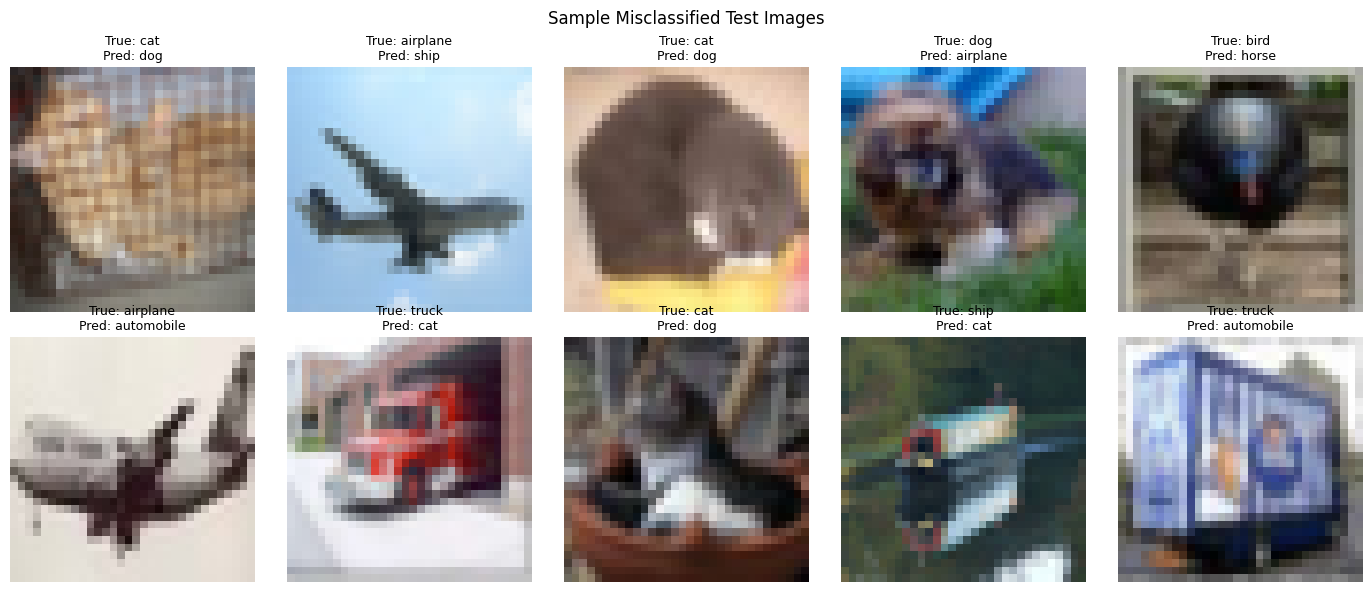

In [81]:
# Display at least 10 incorrectly classified images with True vs Predicted class
misclassified_idx = np.where(y_pred != y_test)[0]
rng_err = np.random.default_rng(SEED)
sample_wrong_idx = rng_err.choice(misclassified_idx, size=10, replace=False)

plt.figure(figsize=(14, 6))
for i, idx in enumerate(sample_wrong_idx):
    img = X_test[idx].reshape(32, 32, 3)   # un-flatten back to an image for display
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Misclassified Test Images")
plt.tight_layout()
plt.show()


**Error Analysis discussion (fill in after viewing `per_class_df`, `top_confused_df`, and the misclassified images above):**

### Error Analysis discussion:

- Easiest classes (highest F1-score): Ship (0.6228), Automobile (0.5774), and Horse (0.5554).
- Most difficult classes (lowest F1-score): Cat (0.3609), Deer (0.3900), and Bird (0.3986).
- Most frequently confused class pairs: Truck → Automobile (311), Cat → Dog (237), and Dog → Cat (225).

The model frequently confuses visually similar classes. For example, cats and dogs are often confused with each other, while trucks are frequently classified as automobiles. This suggests that classes with similar visual features are more difficult for the model to distinguish.

A Dense Neural Network is limited for image classification because the images are flattened before being passed to the network. Flattening removes much of the spatial structure of the image, making it harder for the model to learn relationships between nearby pixels, shapes, and local visual patterns. This helps explain why visually similar classes are frequently confused.


---
## Part 18 — Experiment Tracking

One consolidated table of every major experiment from **both** Before and After Optimization. All values below are pulled from histories already trained earlier in this notebook — nothing is retrained here.

In [83]:
experiment_rows = []

# --- Before Optimization (Parts 3-7) ---
experiment_rows.append({
    "Experiment": "Baseline (Part 3)", "Architecture": "1 hidden layer (128)",
    "LR": 0.001, "Batch": BASELINE_BATCH_SIZE, "Optimizer": "Adam",
    "Dropout": "No", "BatchNorm": "No", "Early Stop": "No",
    "Best Val Acc.": round(max(baseline_history.history['val_accuracy']), 4),
})

for name, history, hidden_desc in [
    ("Shallow (Part 4-7)", shallow_history, "1 hidden layer (256)"),
    ("Medium (Part 4-7)", medium_history, "3 hidden layers (512-256-128)"),
    ("Deep (Part 4-7)", deep_history, "5 hidden layers (512-256-128-64-32)"),
]:
    experiment_rows.append({
        "Experiment": name, "Architecture": hidden_desc,
        "LR": COMMON_LR, "Batch": COMMON_BATCH_SIZE, "Optimizer": "Adam",
        "Dropout": "No", "BatchNorm": "No", "Early Stop": "No",
        "Best Val Acc.": round(max(history.history['val_accuracy']), 4),
    })

# --- After Optimization (Parts 9-15) ---
for lr, history in lr_histories.items():
    experiment_rows.append({
        "Experiment": f"LR Tuning (lr={lr})", "Architecture": SELECTED_ARCHITECTURE,
        "LR": lr, "Batch": COMMON_BATCH_SIZE, "Optimizer": "Adam",
        "Dropout": "No", "BatchNorm": "No", "Early Stop": "No",
        "Best Val Acc.": round(max(history.history['val_accuracy']), 4),
    })

for bs, history in batch_histories.items():
    experiment_rows.append({
        "Experiment": f"Batch Tuning (batch={bs})", "Architecture": SELECTED_ARCHITECTURE,
        "LR": BEST_LR, "Batch": bs, "Optimizer": "Adam",
        "Dropout": "No", "BatchNorm": "No", "Early Stop": "No",
        "Best Val Acc.": round(max(history.history['val_accuracy']), 4),
    })

for opt_label, history in optimizer_histories.items():
    experiment_rows.append({
        "Experiment": f"Optimizer ({opt_label})", "Architecture": SELECTED_ARCHITECTURE,
        "LR": optimizer_configs[opt_label]["learning_rate"], "Batch": BEST_BATCH_SIZE, "Optimizer": opt_label,
        "Dropout": "No", "BatchNorm": "No", "Early Stop": "No",
        "Best Val Acc.": round(max(history.history['val_accuracy']), 4),
    })

reg_settings = {
    "Baseline": {"Dropout": "No", "BatchNorm": "No", "Early Stop": "No"},
    "Dropout (0.3)": {"Dropout": "Yes (0.3)", "BatchNorm": "No", "Early Stop": "No"},
    "Early Stopping": {"Dropout": "No", "BatchNorm": "No", "Early Stop": "Yes"},
    "L2 (1e-4)": {"Dropout": "No", "BatchNorm": "No", "Early Stop": "No"},
}
for label, history in reg_histories_map.items():
    row = {
        "Experiment": f"Regularization ({label})", "Architecture": SELECTED_ARCHITECTURE,
        "LR": BEST_OPTIMIZER_LR, "Batch": BEST_BATCH_SIZE, "Optimizer": BEST_OPTIMIZER_NAME,
        "Best Val Acc.": round(max(history.history['val_accuracy']), 4),
    }
    row.update(reg_settings[label])
    experiment_rows.append(row)

experiment_rows.append({
    "Experiment": "BatchNorm", "Architecture": SELECTED_ARCHITECTURE,
    "LR": BEST_OPTIMIZER_LR, "Batch": BEST_BATCH_SIZE, "Optimizer": BEST_OPTIMIZER_NAME,
    "Dropout": "No", "BatchNorm": "Yes", "Early Stop": "No",
    "Best Val Acc.": round(max(bn_on_history.history['val_accuracy']), 4),
})

experiment_rows.append({
    "Experiment": "Final Model (Part 15)", "Architecture": SELECTED_ARCHITECTURE,
    "LR": BEST_OPTIMIZER_LR, "Batch": BEST_BATCH_SIZE, "Optimizer": BEST_OPTIMIZER_NAME,
    "Dropout": "Yes" if USE_DROPOUT else "No",
    "BatchNorm": "Yes" if USE_BATCHNORM else "No",
    "Early Stop": "Yes" if USE_EARLY_STOPPING else "No",
    "Best Val Acc.": round(max(final_history.history['val_accuracy']), 4),
})

experiment_tracking_df = pd.DataFrame(experiment_rows)
experiment_tracking_df


,Experiment,Architecture,LR,Batch,Optimizer,Dropout,BatchNorm,Early Stop,Best Val Acc.
0,Baseline (Part 3),1 hidden layer (128),0.0010,64,Adam,No,No,No,0.4298
1,Shallow (Part 4-7),1 hidden layer (256),0.0010,64,Adam,No,No,No,0.4532
2,Medium (Part 4-7),3 hidden layers (512-256-128),0.0010,64,Adam,No,No,No,0.4710
3,Deep (Part 4-7),5 hidden layers (512-256-128-64-32),0.0010,64,Adam,No,No,No,0.4734
4,LR Tuning (lr=0.01),medium,0.0100,64,Adam,No,No,No,0.2740
5,LR Tuning (lr=0.001),medium,0.0010,64,Adam,No,No,No,0.4726
6,LR Tuning (lr=0.0001),medium,0.0001,64,Adam,No,No,No,0.5026
7,Batch Tuning (batch=16),medium,0.0001,16,Adam,No,No,No,0.5124
8,Batch Tuning (batch=32),medium,0.0001,32,Adam,No,No,No,0.5106
9,Batch Tuning (batch=64),medium,0.0001,64,Adam,No,No,No,0.5116


---
## Part 19 — Final Conclusion

### Final Conclusion

- As network depth increased from Shallow to Medium to Deep, validation accuracy improved from 0.4532 to 0.4710 and then to 0.4734. The improvement from Medium to Deep was very small.

- Yes, the Deep Network outperformed the Shallow Network on validation data (0.4734 vs. 0.4532), although the improvement was modest.

- The main problem identified from the learning curves was overfitting. Training performance continued to improve while validation performance stopped improving or began to worsen, creating a growing gap between training and validation performance.

- Among the hyperparameters tested, the learning rate had the greatest effect. Changing the learning rate from 0.01 to 0.0001 improved validation accuracy substantially, with 0.0001 achieving 0.5026. Batch-size tuning provided a smaller additional improvement, with batch size 16 reaching 0.5124. Adam also performed better than SGD.

- Early Stopping was the most useful regularization technique. It achieved the highest validation accuracy among the regularization experiments at 0.5162, compared with the regularization baseline of 0.5148. However, the improvement was small.

- No, the model with the highest training accuracy did not necessarily generalize best. Higher training performance did not consistently produce higher validation performance, demonstrating that training accuracy alone is not a reliable measure of generalization.

- The Final Model used the Medium architecture with hidden layers [512, 256, 128], Adam optimizer, learning rate 0.0001, batch size 16, and Early Stopping. The final configuration was selected based on the experimental evidence from the architecture and hyperparameter-tuning stages.

- The evidence showed that the Medium architecture provided strong validation performance without the additional complexity of the Deep network, while learning rate 0.0001 and batch size 16 improved validation performance. The regularization experiments produced only small improvements over the baseline.

- The Final Model achieved a test accuracy of 0.4962 (49.62%). Although the tuning process improved the original Dense Neural Network, its performance remains limited for image classification. Flattening the images removes their spatial structure, making it difficult for a fully connected network to learn local visual patterns. A CNN would likely be more suitable because it preserves and exploits spatial information.


---
## Part 20 — Reflection: Preparing for Computer Vision

**What are the limitations of using a fully connected Dense Neural Network for image data?**

Throughout this project, every 32×32×3 image was flattened into a vector of 3072 independent input values before being fed to the network.

**What happens to the spatial structure of the image after flattening?**
Flattening destroys the 2D spatial layout of the image. A pixel's row/column position and its relationship to neighboring pixels are lost — the image becomes just a long, unordered list of 3072 numbers. Two pixels that were physically adjacent in the original image (and therefore likely related, e.g., part of the same edge or object) end up as two arbitrary, unrelated positions in the input vector.

**Does the Dense Network explicitly understand which pixels are next to each other?**
No. A Dense layer treats every one of the 3072 input values as an independent feature and connects each one to every neuron with its own separate weight. There is nothing in the architecture that encodes "these two pixels are neighbors" — the network would have to *learn* any notion of locality purely from data, which is inefficient and requires far more parameters than architectures that build locality in from the start.

**Why might this representation make image classification difficult?**
Because Dense layers can't exploit the fact that meaningful visual patterns (edges, textures, shapes) are local and repeat in different positions across an image. The network must learn a mostly separate set of weights for a pattern appearing in the top-left of the image versus the same pattern appearing in the bottom-right, instead of reusing one learned pattern-detector everywhere. This drives up the parameter count and makes generalization to new images (with objects in slightly different positions, scales, or orientations) harder.

**What characteristics would an architecture designed specifically for images need to preserve?**
It would need to:
- Preserve the 2D spatial arrangement of pixels instead of flattening it away.
- Exploit **locality** — that nearby pixels are more related than distant ones.
- Support **weight sharing / translation invariance** — the same learned feature detector (e.g., an edge detector) should be reusable at every position in the image, rather than learning a separate detector per location.
- Build a spatial hierarchy — combining simple local patterns (edges) into increasingly complex ones (textures, parts, objects) at deeper layers.

This is precisely the motivation for **Convolutional Neural Networks (CNNs)**, which use convolutional filters that slide across the image, sharing weights and preserving spatial structure — the topic of the next unit.
